# Contractile cable - actin & myosin

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math, scipy, skimage, os
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,

    'svg.fonttype':'none',
    'pdf.fonttype': 42,

    'axes.linewidth': 0.5,

    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,

    'xtick.major.size': 2,
    'ytick.major.size': 2,
    'xtick.major.pad': 1,
    'ytick.major.pad': 1,

    'axes.labelpad': 1
})

In [6]:
import tifffile as tf
import nd2

# Load the data information

In [7]:
data_info = pd.read_excel('B:\\archive\\xtong\\xin home drive\\data_meroblastic\\majority_data_info.xlsx', sheet_name = 'actin_highres')
# data_info = data_info[data_info.cortex_flow_analysis.isin(['wt', 'carhoa'])] 
data_info = data_info[data_info.cortex_flow_analysis.isin(['myosin'])] 

staging_cols = ["m1", "ck1", "df1", "afz1", "pfa1", "m2", 'septum1', "ck2", "start", "stop"]
data_info[staging_cols] = data_info[staging_cols].apply(pd.to_numeric, errors="coerce").astype("Int64")
rep_folders = os.listdir()

data_info

,rep_name,experiment,folder,file_name,embryo,raw_data,movie_name,pivlabtxt_folder,objective,notes,...,stop,vmin,vmax,cortex_flow_analysis,no_quanti,transitional_phase_CB_width,cb_width,afz_width,pro_rotate_for_edge,deal_with_edge
149,rep151,NaN,NaN,XIN211129_CSU1_MylEGFP_UtrmCh016_40x_e1_max.tif,e1,B:\archive\xtong\xint_raw_data\nikon spinning ...,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,myosin,NaN,NaN,NaN,NaN,NaN,NaN
150,rep152,NaN,NaN,XIN211129_CSU1_MylEGFP_UtrmCh017_40x_e2_max.tif,e2,B:\archive\xtong\xint_raw_data\nikon spinning ...,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,myosin,NaN,NaN,NaN,NaN,NaN,NaN
151,rep153,NaN,NaN,XIN211129_CSU1_MylEGFP_UtrmCh018_40x_e3_max.tif,e3,B:\archive\xtong\xint_raw_data\nikon spinning ...,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,myosin,NaN,NaN,NaN,NaN,NaN,NaN
152,rep154,NaN,NaN,XIN220208_CSU1_Myl_Utr_001,e1,B:\archive\xtong\xint_raw_data\nikon spinning ...,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,myosin,NaN,NaN,NaN,NaN,NaN,NaN
153,rep155,NaN,NaN,XIN220208_CSU1_Myl_Utr_003,e2,B:\archive\xtong\xint_raw_data\nikon spinning ...,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,myosin,NaN,NaN,NaN,NaN,NaN,NaN
154,rep156,NaN,NaN,XIN220208_CSU1_Myl_Utr_004,e3,B:\archive\xtong\xint_raw_data\nikon spinning ...,NaN,NaN,NaN,NaN,...,<NA>,150.0,900.0,myosin,NaN,NaN,NaN,NaN,NaN,NaN
155,rep157,NaN,NaN,XIN220208_CSU1_Myl_Utr_005,e4,B:\archive\xtong\xint_raw_data\nikon spinning ...,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,myosin,NaN,NaN,NaN,NaN,NaN,NaN
156,rep158,NaN,NaN,XIN220208_CSU1_Myl_Utr_006,e5,B:\archive\xtong\xint_raw_data\nikon spinning ...,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,myosin,NaN,NaN,NaN,NaN,NaN,NaN
157,rep159,NaN,NaN,XIN220325_CSU1_Myl_Utr_001,e1,B:\archive\xtong\xint_raw_data\nikon spinning ...,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,myosin,NaN,NaN,NaN,NaN,NaN,NaN
158,rep160,NaN,NaN,XIN220325_CSU1_Myl_Utr_003,e2,B:\archive\xtong\xint_raw_data\nikon spinning ...,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,myosin,NaN,NaN,NaN,NaN,NaN,NaN


# Actin and myosin intensity across the contractile cable

## Strategy 1 - work with Z-sectional views (optional)

### Pre-process the data

In [8]:
# for i in data_info.index[10:]:
#     replicate = data_info.loc[i]
#     rep_name = replicate.rep_name
#     raw_data = replicate.raw_data
#     print(rep_name)
#     rep_folder = rep_name

#     movie_name = rep_folder + '//' + rep_name + '_roi4.tif'
#     pixel_size, time_interval = replicate.pixel_size, replicate.time_interval
#     ck1 = replicate.ck1
#     ck1_5mp = ck1 + round(5*60/time_interval) -1

#     print('frames selected:', ck1_5mp)
#     with nd2.ND2File(raw_data) as f:
#         raw_data_lazy_array = f.to_xarray()
#     print('dim:', raw_data_lazy_array.sizes)

#     data = raw_data_lazy_array.isel(T=ck1_5mp).data.compute()
#     data = data.astype(np.float32)
#     # data_averaged = np.mean(data, axis=0)
#     skimage.io.imsave(rep_folder + '//' + rep_name + '_raw_to_be_procossed_1.tif', data)
      # print(' ')

### Segment the cell surface

rep154
bg: 235.6548 136.37263


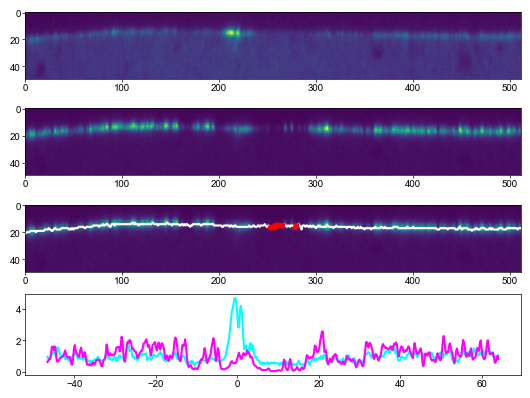

rep155
bg: 229.82971 141.21748


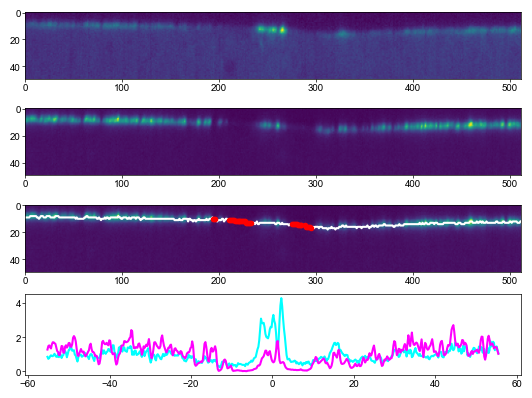

rep156
bg: 217.90761 150.47693


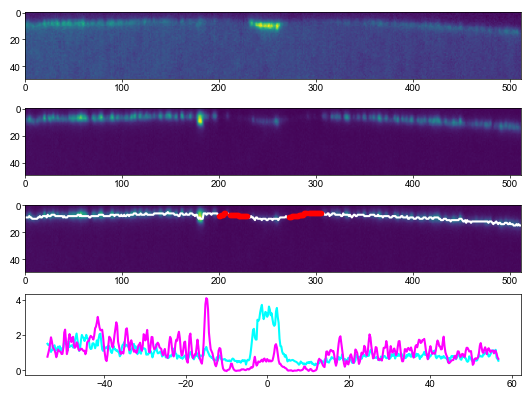

rep157
bg: 225.12068 129.11638


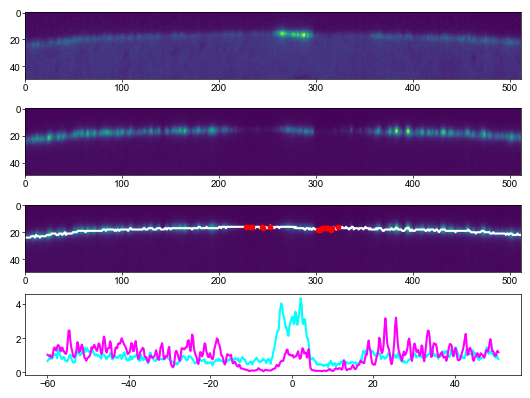

rep158
bg: 217.97409 128.09235


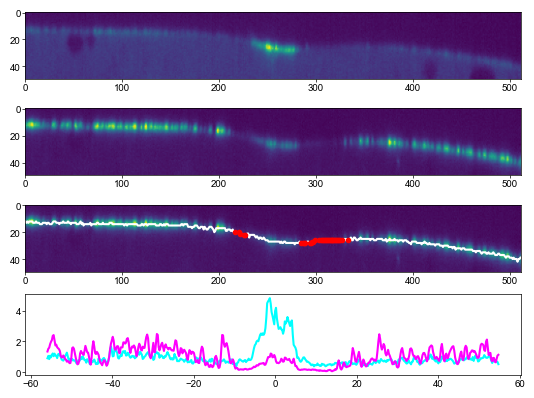

rep159
bg: 147.02612 111.964325


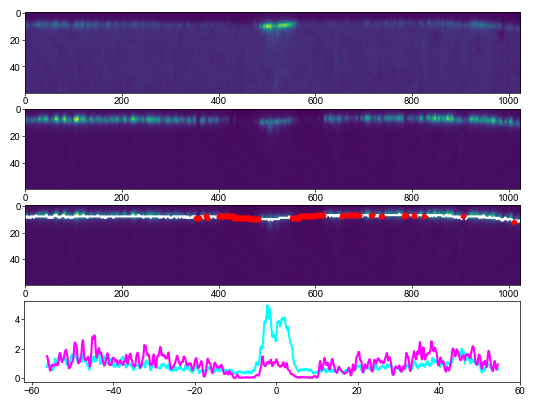

rep160
bg: 144.97227 108.542946


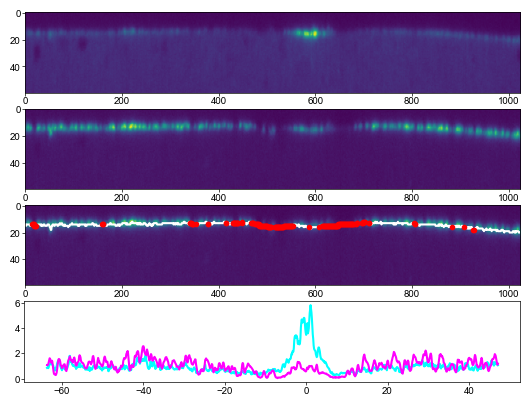

rep161
bg: 130.16223 106.294556


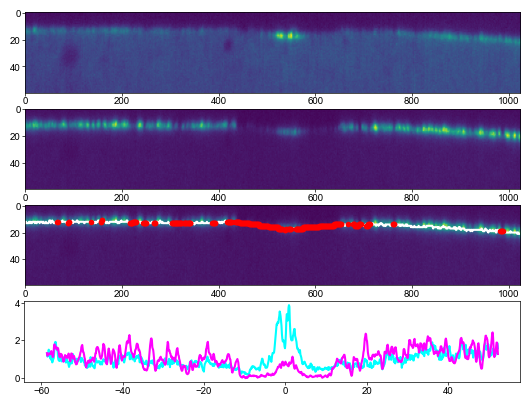

In [9]:
poses = []
myos = []
acts = []

for i in data_info.index[3:]:
    replicate = data_info.loc[i]
    rep_name = replicate.rep_name
    raw_data = replicate.raw_data
    print(rep_name)
    rep_folder = rep_name

    movie_name = rep_folder + '//' + rep_name + '_roi4.tif'
    pixel_size, voxel_depth, time_interval = replicate.pixel_size, replicate.voxel_depth, replicate.time_interval
    ck1 = replicate.ck1
    ck1_5mp = ck1 + round(5*60/time_interval) -1

    with nd2.ND2File(raw_data) as f:
        raw_data_lazy_array = f.to_xarray()

    data = skimage.io.imread(rep_folder + '//' + rep_name + '_raw_to_be_procossed_1.tif')
    data[data==0] = np.nan
    zs = raw_data_lazy_array.sizes['Z']
    _, ys, xs = data.shape
    data = data.reshape([zs, 2, ys, xs])

    myo_bg = np.nanmean(data[0,0])
    act_bg = np.nanmean(data[0,1])
    print('bg:', myo_bg, act_bg)

    movie_x_band_width = xs * 1/50
    movie_x_band_center = xs/2
    movie_x_band =  np.round([movie_x_band_center - movie_x_band_width/2, movie_x_band_center + movie_x_band_width/2], 0).astype(int)

    data_averaged = np.average(data[:,:,:, movie_x_band[0]:movie_x_band[1]], axis=3)

    myo = data_averaged[:, 0]
    act = data_averaged[:, 1]

    fig, axs = plt.subplots(4,1)
    axs[0].imshow(data_averaged[:, 0], aspect=voxel_depth/pixel_size)
    axs[1].imshow(data_averaged[:, 1], aspect=voxel_depth/pixel_size)
    axs[2].imshow(data_averaged[:, 1], aspect=voxel_depth/pixel_size)

    surface = np.zeros(ys)
    for y in range(ys):
        zstick = act[:, y]
        if np.ptp(zstick)>50:
            surface[y] = np.argmax(zstick)
        else:
            surface[y] = np.nan

    nans = np.isnan(surface)
    xs_coord = np.arange(ys)

    surface[nans] = np.interp(xs_coord[nans], xs_coord[~nans], surface[~nans])
    surface = np.round(surface).astype(int)
    axs[2].plot(xs_coord, surface, color='white')
    axs[2].plot(xs_coord[nans], surface[nans], '.', color='red')

    # myo_int = myo[surface, np.arange(ys)]
    # act_int = act[surface, np.arange(ys)]
    act_int = np.mean([act[surface+i, np.arange(ys)] for i in range(-1,2)], axis=0)
    myo_int = np.mean([myo[surface+i, np.arange(ys)] for i in range(-1,2)], axis=0)

    myo_int -= myo_bg
    act_int -= act_bg

    myo_int /= np.mean(myo_int)
    act_int /= np.mean(act_int)

    myo_int_blur = scipy.ndimage.gaussian_filter(myo_int, sigma=15)
    cable_center = np.argmax(myo_int_blur)
    position = (np.arange(ys) - cable_center)*pixel_size

    axs[3].plot(position, myo_int, color='cyan')
    axs[3].plot(position, act_int, color='magenta')

    plt.show()

    poses.append(position)
    myos.append(myo_int)
    acts.append(act_int)


### Align all replicates

False
False
True
False
False
True
False
True


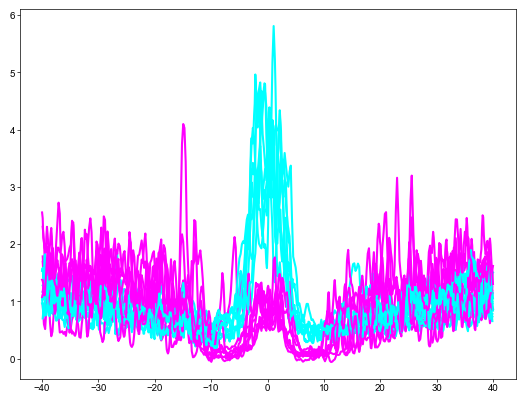

In [10]:
pixel_size_new = 0.216609
pos_range_new = round(40/0.216609)
pos_new = (np.arange(pos_range_new*2)-pos_range_new)*pixel_size_new

myos_aligned, acts_aligned = [], []

for pos, myo, act in zip(poses, myos, acts):
    filter = (pos>-40) & (pos<40)
    print(np.any(act<0))

    myo_new = scipy.interpolate.interp1d(pos[filter], myo[filter], axis=0, kind="linear", bounds_error=False, fill_value=np.nan)(pos_new)
    act_new = scipy.interpolate.interp1d(pos[filter], act[filter], axis=0, kind="linear", bounds_error=False, fill_value=np.nan)(pos_new)

    plt.plot(pos[filter], myo[filter], color='cyan')
    plt.plot(pos[filter], act[filter], color='magenta')
    # plt.plot(pos_new, myo_new)
    # plt.plot(pos_new, act_new)
    # plt.show()

    myos_aligned.append(myo_new)
    acts_aligned.append(act_new)

myo_aligned_mean = np.mean(myos_aligned, axis=0)
act_aligned_mean = np.mean(acts_aligned, axis=0)

### Plot for the paper

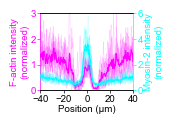

In [11]:
colors = ['cyan', 'magenta']

fig, ax = plt.subplots(figsize=[1.2, 1])
ax1 = ax.twinx()

for pos, myo, act in zip(poses, myos, acts):
    filter = (pos>-40) & (pos<40)

    lw, alpha = 0.4,  0.2
    ax.plot(pos[filter], act[filter], color=colors[1], zorder=-2, alpha=alpha, lw=lw)
    ax1.plot(pos[filter], myo[filter], color=colors[0], zorder=-2, alpha=alpha, lw=lw)

lw=0.8
ax.plot(pos_new, act_aligned_mean, color=colors[1], lw=lw)
ax1.plot(pos_new, myo_aligned_mean, color=colors[0], lw=lw)

ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(colors[1])
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_color(colors[0])
ax.tick_params(axis='y', colors=colors[1], labelcolor=colors[1])
ax1.tick_params(axis='y', colors=colors[0], labelcolor=colors[0])

ax.set_xlim(-40, 40)
ax.set_xticks([-40, -20, 0, 20, 40])

ax.set_ylim(0, 3)
# ax.set_yticks(np.arange(0,2.2, 0.5))

ax1.set_ylim(0, 6)
# ax1.set_yticks(np.arange(0, 5, 1))

ax.set_xlabel('Position (\u03BCm)')
ax.set_ylabel('F-actin intensity\n(normalized)', color=colors[1])
ax1.set_ylabel('Myosin-2 intensity\n(normalized)', color=colors[0])
plt.savefig('actin_myosin_coloc.svg')
plt.show()

N = 8 clutches from 2 different days, n = 8 embryos.

In [17]:
rep_names = [data_info.loc[i].rep_name for i in data_info.index[3:]]
file_names = [data_info.loc[i].file_name for i in data_info.index[3:]]
embryos = [data_info.loc[i].embryo for i in data_info.index[3:]]

dfs = []

list1 = pos_new
list2 = act_aligned_mean
list3 = myo_aligned_mean
list4 = ['Mean'] * len(list3)

df = pd.DataFrame({'Replicate #': list4, 'Position (um)': list1, 'F-actin intensity (normalized)': list2, 'Myosin-2 intensity (normalized)':list3})
dfs.append(df)

for i in range(len(poses)):
    pos, act, myo = poses[i], myos[i], acts[i]

    filter = (pos>-40) & (pos<40)

    list1 = pos[filter]
    list2 = act[filter]
    list3 = myo[filter]
    list4 = [rep_names[i]] * len(list3)
    list5 = [file_names[i]] * len(list3)
    list6 = [embryos[i]] * len(list3)

    df = pd.DataFrame({'Replicate #': list4, 'Position (um)': list1, 'F-actin intensity (normalized)': list2, 'Myosin-2 intensity (normalized)':list3,
                       'Experiment date': list5, 'Embryo #': list6})
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all.fillna('NA', inplace=True)
df_all.to_excel('actin_myosin_coloc_excel_figs2b.xlsx', index=False)

C:\Users\xtong\AppData\Local\Temp\ipykernel_13100\2941684016.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NA' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_all.fillna('NA', inplace=True)


## Strategy 2 - work with maximum projections

rep154


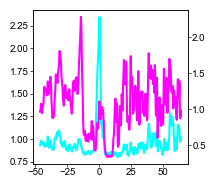

rep155


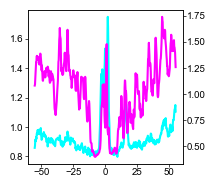

rep156


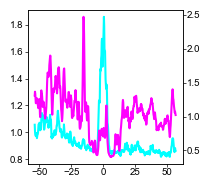

rep157


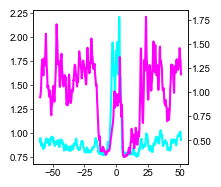

rep158


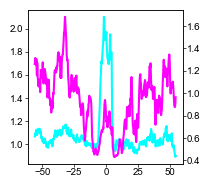

rep159


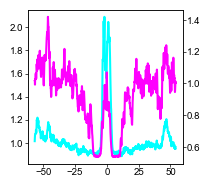

rep160


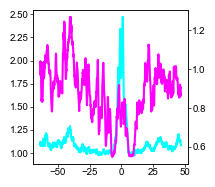

rep161


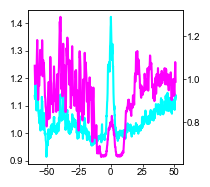

In [4]:
poses = []
myos = []
acts = []

# fig, ax = plt.subplots()
# ax1 = ax.twinx()

for i in data_info.index[3:]:
    replicate = data_info.loc[i]
    rep_name = replicate.rep_name
    print(rep_name)
    rep_folder = next(rep_folder for rep_folder in rep_folders if rep_name in rep_folder)
    movie_name = rep_folder + '//' + rep_name + '_roi4.tif'
    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval
    ck1 = replicate.ck1

    ck1_5mp = ck1 + round(5*60/time_interval)

    movie = tf.memmap(movie_name)
    fs, _, ys, xs = movie.shape

    movie_x_band_width = xs * 1/50
    movie_x_band_center = xs/2
    movie_x_band =  np.round([movie_x_band_center - movie_x_band_width/2, movie_x_band_center + movie_x_band_width/2], 0).astype(int)

    movie_ck1_5mp = movie[ck1_5mp:ck1_5mp+5].astype(float)
    movie_ck1_5mp[movie_ck1_5mp==0] = np.nan
    intensity_in_the_middle_ck1_5mp = np.nanmean(movie_ck1_5mp[:, :, :, movie_x_band[0]:movie_x_band[1]], axis=(0, 3))
    scale_factors = np.nanmean(movie_ck1_5mp, axis=(1,2,3))
    myo, act = intensity_in_the_middle_ck1_5mp
    myo /= scale_factors[0]
    act /= scale_factors[1]

    myo_blur = scipy.ndimage.gaussian_filter(myo, sigma=15)
    act_blur = scipy.ndimage.gaussian_filter(act, sigma=15)
    cable_center = np.argmax(myo_blur)
    position = (np.arange(ys) - cable_center)*pixel_size
    
    # fig, ax = plt.subplots()
    # ax.plot(position, myo_blur, color='cyan')
    # ax1 = ax.twinx()
    # ax1.plot(position, act_blur, color='magenta')
    # plt.show()

    # myo /= np.max(myo_blur)

    fig, ax = plt.subplots(figsize=[2,2])
    ax1 = ax.twinx()
    ax.plot(position, myo, color='cyan')
    # ax.set_ylim(0, 1)
    ax1.plot(position, act, color='magenta')
    plt.show()

    poses.append(position)
    myos.append(myo)
    acts.append(act)
# plt.show()

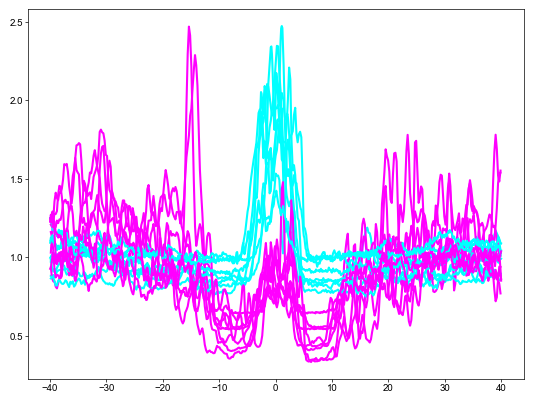

In [5]:
pixel_size_new = 0.216609
pos_range_new = round(40/0.216609)
pos_new = (np.arange(pos_range_new*2)-pos_range_new)*pixel_size_new

myos_aligned, acts_aligned = [], []

for pos, myo, act in zip(poses, myos, acts):
    filter = (pos>-40) & (pos<40)

    myo_new = scipy.interpolate.interp1d(pos[filter], myo[filter], axis=0, kind="linear", bounds_error=False, fill_value=np.nan)(pos_new)
    act_new = scipy.interpolate.interp1d(pos[filter], act[filter], axis=0, kind="linear", bounds_error=False, fill_value=np.nan)(pos_new)

    plt.plot(pos[filter], myo[filter], color='cyan')
    plt.plot(pos[filter], act[filter], color='magenta')
    # plt.plot(pos_new, myo_new)
    # plt.plot(pos_new, act_new)
    # plt.show()

    myos_aligned.append(myo_new)
    acts_aligned.append(act_new)

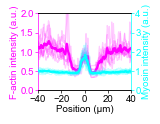

In [6]:
myo_aligned_mean = np.mean(myos_aligned, axis=0)
act_aligned_mean = np.mean(acts_aligned, axis=0)

colors = ['cyan', 'magenta']

fig, ax = plt.subplots(figsize=[1.2, 1])
ax1 = ax.twinx()

for pos, myo, act in zip(poses, myos, acts):
    filter = (pos>-40) & (pos<40)

    lw, alpha = 0.8,  0.2
    ax.plot(pos[filter], act[filter], color=colors[1], zorder=-2, alpha=alpha, lw=lw)
    ax1.plot(pos[filter], myo[filter], color=colors[0], zorder=-2, alpha=alpha, lw=lw)

lw=1.6
ax.plot(pos_new, act_aligned_mean, color=colors[1], lw=lw)
ax1.plot(pos_new, myo_aligned_mean, color=colors[0], lw=lw)

ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(colors[1])
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_color(colors[0])
ax.tick_params(axis='y', colors=colors[1], labelcolor=colors[1])
ax1.tick_params(axis='y', colors=colors[0], labelcolor=colors[0])

ax.set_xlim(-40, 40)
ax.set_xticks([-40, -20, 0, 20, 40])
ax.set_ylim(0, 2)
ax.set_yticks(np.arange(0,2.2, 0.5))

ax1.set_ylim(0, 4)
ax1.set_yticks(np.arange(0, 5, 1))

ax.set_xlabel('Position (\u03BCm)')
ax.set_ylabel('F-actin intensity (a.u.)', color=colors[1])
ax1.set_ylabel('Myosin intensity (a.u.)', color=colors[0])
plt.savefig('actin_myosin_coloc2.svg')
plt.show()

# Actin and myosin intensity at the edge

## Pre-process the data

In [18]:
for i in data_info.index:
    replicate = data_info.loc[i]
    rep_name = replicate.rep_name
    raw_data = replicate.raw_data
    print(rep_name)
    rep_folder = rep_name

    movie_name = rep_folder + '//' + rep_name + '_roi4.tif'
    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval
    ck1 = replicate.ck1
    ck1_5mp = ck1 + round(5*60/time_interval) -1

    print(ck1, ck1_5mp+1)

rep151
50 84
rep152
89 123
rep153
117 151
rep154
4 57
rep155
128 181
rep156
173 226
rep157
99 152
rep158
180 233
rep159
63 108
rep160
17 61
rep161
96 134


rep151
['rep151//XIN211129_CSU1_MylEGFP_UtrmCh016_40x_e1_max.tif_line_profile.csv']
rep152
['rep152//XIN211129_CSU1_MylEGFP_UtrmCh017_40x_e2_max.tif_line_profile.csv']
rep153
['rep153//XIN211129_CSU1_MylEGFP_UtrmCh018_40x_e3_max.tif_line_profile.csv', 'rep153//XIN211129_CSU1_MylEGFP_UtrmCh018_40x_e3_max.tif_line_profile2.csv']
rep154
['rep154//rep154_XIN220208_CSU1_Myl_Utr_001_e1_max.tif_line_profile.csv']
rep155
[]
rep156
['rep156//XIN220208_CSU1_Myl_Utr_004_max.tif_line_profile.csv']
rep157
[]
rep158
[]
rep159
[]
rep160
[]
rep161
[]


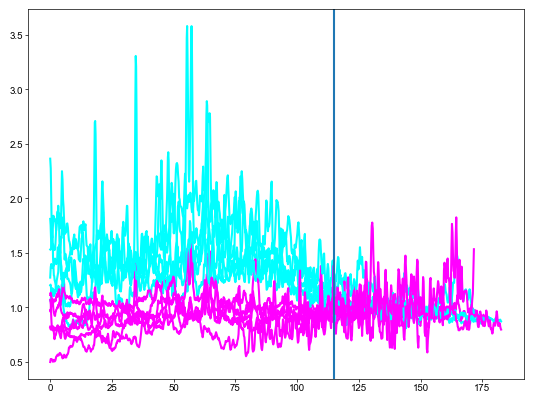

In [19]:
poses = []
myos = []
acts = []

for i in data_info.index[:]:
    replicate = data_info.loc[i]
    rep_name = replicate.rep_name
    raw_data = replicate.raw_data
    print(rep_name)
    rep_folder = rep_name

    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval
    ck1 = replicate.ck1
    ck1_5mp = ck1 + round(5*60/time_interval) -1

    # os.listdir(rep_folder))
    line_profiles = [pd.read_csv(rep_folder + '//' + file) for file in os.listdir(rep_folder) if'line_profile' in file]
    print([(rep_folder + '//' + file) for file in os.listdir(rep_folder) if'line_profile' in file])
    for line_profile in line_profiles:

        pos = np.array(line_profile.Position * pixel_size)
        myo, act = np.array(line_profile.Channel1), np.array(line_profile.Channel2)

        filter = (pos>=130) & (pos<=140)
        myo_scale_factor, act_scale_factor = np.mean(myo[filter]), np.mean(act[filter])
        myo, act = myo/myo_scale_factor, act/act_scale_factor

        plt.plot(pos, myo, color='cyan')
        plt.plot(pos, act, color='magenta')

        poses.append(pos)
        myos.append(myo)
        acts.append(act)

plt.axvline(x = 115)

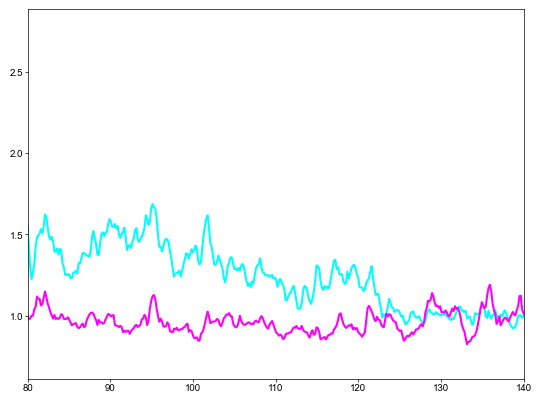

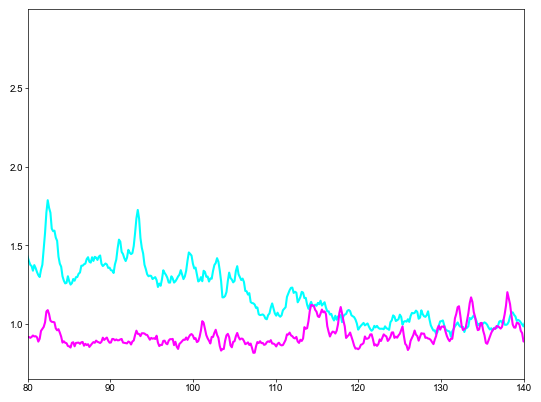

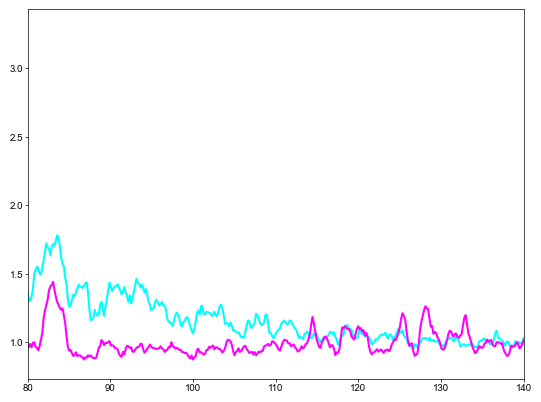

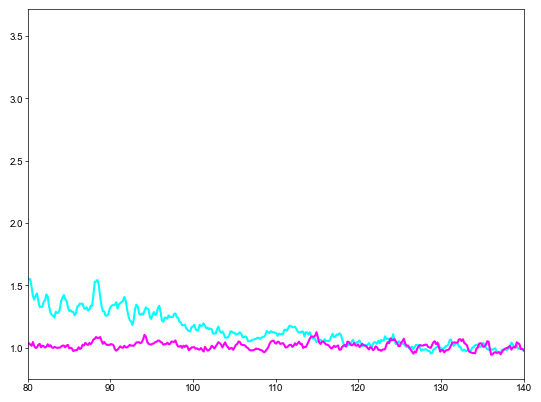

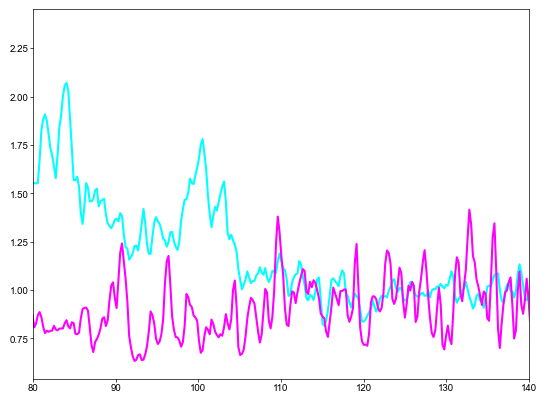

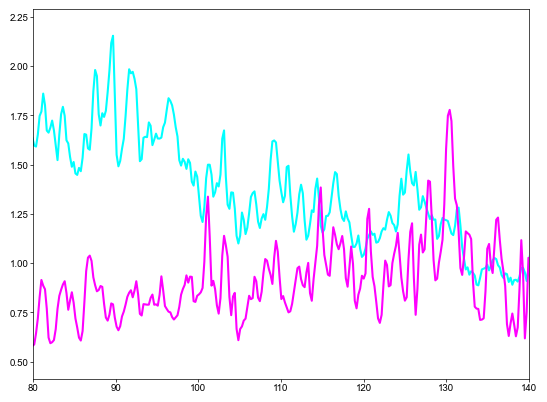

In [20]:
pixel_size_new = 0.65
pos_range_new = round(40/0.216609)
pos_new = np.arange(0, 300) * pixel_size_new

myos_aligned, acts_aligned = [], []

for pos, myo, act in zip(poses, myos, acts):

    myo_new = scipy.interpolate.interp1d(pos, myo, axis=0, kind="linear", bounds_error=False, fill_value=np.nan)(pos_new)
    act_new = scipy.interpolate.interp1d(pos, act, axis=0, kind="linear", bounds_error=False, fill_value=np.nan)(pos_new)
    
    plt.plot(pos, myo, color='cyan')
    plt.plot(pos, act, color='magenta')
    plt.gca().set_xlim(80, 140)
    plt.show()

    myos_aligned.append(myo_new)
    acts_aligned.append(act_new)


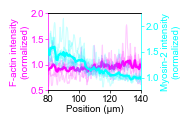

In [22]:
myo_aligned_mean = np.mean(myos_aligned, axis=0)
act_aligned_mean = np.mean(acts_aligned, axis=0)

colors = ['cyan', 'magenta']

fig, ax = plt.subplots(figsize=[1.2, 1])
ax1 = ax.twinx()

for pos, myo, act in zip(poses, myos, acts):

    lw, alpha = 0.8,  0.2
    ax.plot(pos, act, color=colors[1], zorder=-2, alpha=alpha, lw=lw)
    ax1.plot(pos, myo, color=colors[0], zorder=-2, alpha=alpha, lw=lw)

lw=1.6

ax.plot(pos_new, act_aligned_mean, color=colors[1], lw=lw)
ax1.plot(pos_new, myo_aligned_mean, color=colors[0], lw=lw)


ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(colors[1])
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_color(colors[0])
ax.tick_params(axis='y', colors=colors[1], labelcolor=colors[1])
ax1.tick_params(axis='y', colors=colors[0], labelcolor=colors[0])

ax.set_xlim(80, 140)
ax.set_xticks(np.arange(80, 141, 20))
ax.set_ylim(0.5, 2)
ax.set_yticks(np.arange(0.5, 2.1, 0.5))

ax1.set_ylim(0.75, 2.25)
ax1.set_yticks(np.arange(1, 2.1, 0.5))
ax.set_xlabel('Position (\u03BCm)')
ax.set_ylabel('F-actin intensity\n(normalized)', color=colors[1])
ax1.set_ylabel('Myosin-2 intensity\n(normalized)', color=colors[0])
plt.savefig('actin_myosin_coloc3.svg')
plt.show()

In [25]:
rep_names = [data_info.loc[i].rep_name for i in data_info.index[3:]]
file_names = [data_info.loc[i].file_name for i in data_info.index[3:]]
embryos = [data_info.loc[i].embryo for i in data_info.index[3:]]

dfs = []

filter = (pos_new>80) & (pos_new<140)

list1 = pos_new[filter]
list2 = act_aligned_mean[filter]
list3 = myo_aligned_mean[filter]
list4 = ['Mean'] * len(list3)

df = pd.DataFrame({'Replicate #': list4, 'Position (um)': list1, 'F-actin intensity (normalized)': list2, 'Myosin-2 intensity (normalized)':list3})
dfs.append(df)

for i in range(len(poses)):
    pos, act, myo = poses[i], myos[i], acts[i]

    filter = (pos>80) & (pos<140)

    list1 = pos[filter]
    list2 = act[filter]
    list3 = myo[filter]
    list4 = [rep_names[i]] * len(list3)
    list5 = [file_names[i]] * len(list3)
    list6 = [embryos[i]] * len(list3)

    df = pd.DataFrame({'Replicate #': list4, 'Position (um)': list1, 'F-actin intensity (normalized)': list2, 'Myosin-2 intensity (normalized)':list3,
                       'Experiment date': list5, 'Embryo #': list6})
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all.fillna('NA', inplace=True)
df_all.to_excel('actin_myosin_coloc3_excel_figs2b_right.xlsx', index=False)

# Actin and myosin kymograph

rep155
bg: 229.82971 141.21748
bg: 311.9374 150.12157


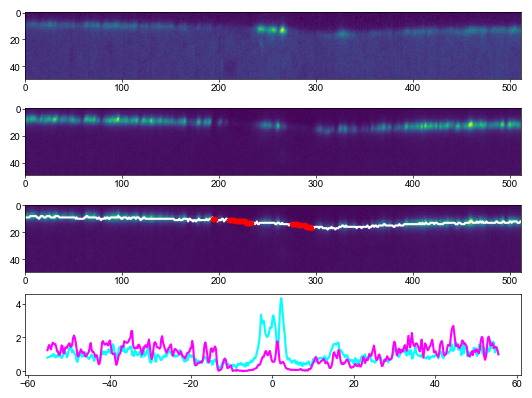

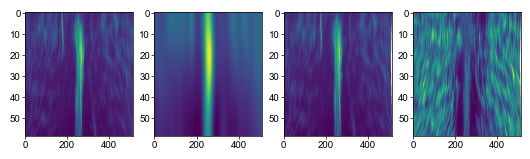

rep156
bg: 217.90761 150.47693
bg: 288.8437 140.03864


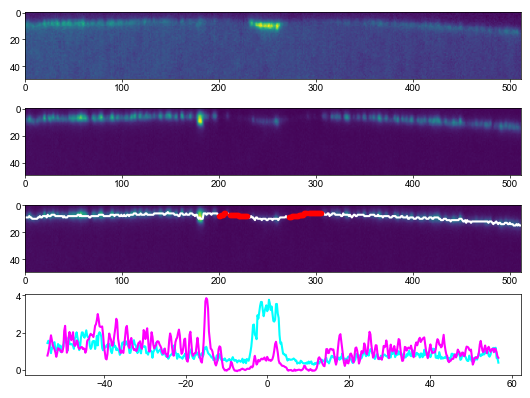

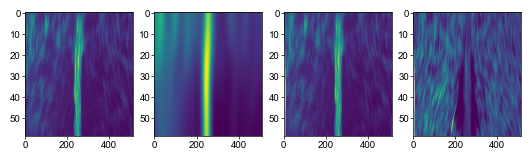

rep157
bg: 225.12068 129.11638
bg: 346.86996 147.29692


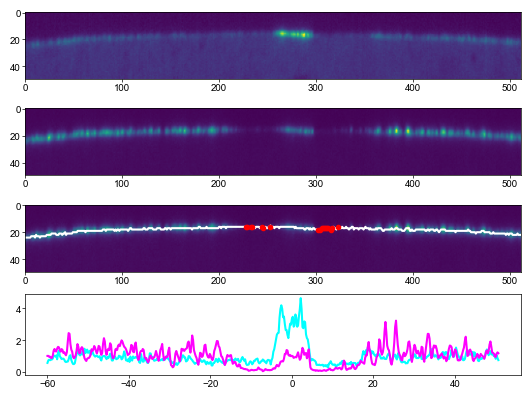

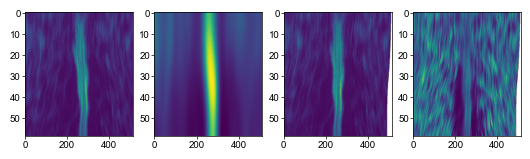

rep158
bg: 217.97409 128.09235
bg: 330.01752 153.19902


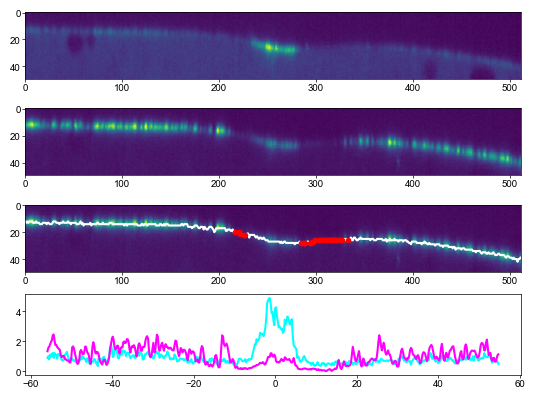

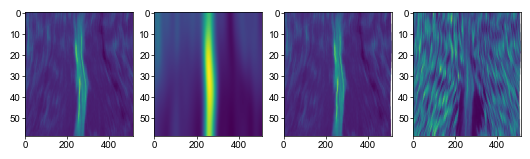

In [44]:
time_pixels = []
myo_kymos = []
myo_kymo_realigneds = []
act_kymos = []
act_kymo_realigneds = []


for i in data_info.index[4:8]:
    replicate = data_info.loc[i]
    rep_name = replicate.rep_name
    raw_data = replicate.raw_data
    print(rep_name)
    rep_folder = rep_name

    movie_name = rep_folder + '//' + rep_name + '_roi4.tif'
    pixel_size, voxel_depth, time_interval = replicate.pixel_size, replicate.voxel_depth, replicate.time_interval
    ck1 = replicate.ck1
    ck1_5mp = ck1 + round(5*60/time_interval) -1

    with nd2.ND2File(raw_data) as f:
        raw_data_lazy_array = f.to_xarray()

    data = skimage.io.imread(rep_folder + '//' + rep_name + '_raw_to_be_procossed_1.tif')
    data[data==0] = np.nan
    zs = raw_data_lazy_array.sizes['Z']
    _, ys, xs = data.shape
    data = data.reshape([zs, 2, ys, xs])

    myo_bg = np.nanmean(data[0,0])
    act_bg = np.nanmean(data[0,1])
    print('bg:', myo_bg, act_bg)

    myo_bulk = np.nanmean(data[-1,0])
    act_bulk = np.nanmean(data[-1,1])
    print('bg:', myo_bulk, act_bulk)

    movie_x_band_width = xs * 1/50
    movie_x_band_center = xs/2
    movie_x_band =  np.round([movie_x_band_center - movie_x_band_width/2, movie_x_band_center + movie_x_band_width/2], 0).astype(int)

    data_averaged = np.average(data[:,:,:, movie_x_band[0]:movie_x_band[1]], axis=3)

    myo = data_averaged[:, 0]
    act = data_averaged[:, 1]

    fig, axs = plt.subplots(4,1)
    axs[0].imshow(data_averaged[:, 0], aspect=voxel_depth/pixel_size)
    axs[1].imshow(data_averaged[:, 1], aspect=voxel_depth/pixel_size)
    axs[2].imshow(data_averaged[:, 1], aspect=voxel_depth/pixel_size)

    surface = np.zeros(ys)
    for y in range(ys):
        zstick = act[:, y]
        if np.ptp(zstick)>50:
            surface[y] = np.argmax(zstick)
        else:
            surface[y] = np.nan

    nans = np.isnan(surface)
    xs_coord = np.arange(ys)

    surface[nans] = np.interp(xs_coord[nans], xs_coord[~nans], surface[~nans])
    surface = np.round(surface).astype(int)
    axs[2].plot(xs_coord, surface, color='white')
    axs[2].plot(xs_coord[nans], surface[nans], '.', color='red')

    myo_int = myo[surface, np.arange(ys)]
    act_int = act[surface, np.arange(ys)]

    myo_int -= myo_bg
    act_int -= act_bg

    myo_int /= np.mean(myo_int)
    act_int /= np.mean(act_int)

    myo_int_blur = scipy.ndimage.gaussian_filter(myo_int, sigma=15)
    cable_center = np.argmax(myo_int_blur)
    position = (np.arange(ys) - cable_center)*pixel_size

    axs[3].plot(position, myo_int, color='cyan')
    axs[3].plot(position, act_int, color='magenta')

    plt.show()

    kymostart, kymoend = ck1, round(ck1 + 5.5*60/time_interval)
    movie = skimage.io.imread(movie_name)

    to_kymo = movie[kymostart:kymoend]
    myo_kymo = np.nanmean(to_kymo[:, 0, :, movie_x_band[0]:movie_x_band[1]], axis=2)
    act_kymo = np.nanmean(to_kymo[:, 1, :, movie_x_band[0]:movie_x_band[1]], axis=2)

    # myo_kymo -=myo_bg
    act_kymo -=act_bg

    myo_kymo -=myo_bulk

    myo_kymo /= np.nanmean(myo_kymo[30])
    act_kymo /= np.nanmean(act_kymo[30])

    myo_kymo_gaussian = scipy.ndimage.gaussian_filter(myo_kymo, sigma=10)
    myo_kymo_realigned = np.zeros_like(myo_kymo)
    act_kymo_realigned = np.zeros_like(myo_kymo)
    kymo_fs, _ = myo_kymo.shape
    for kymo_f in range(kymo_fs):
        f_slice_center = np.argmax(myo_kymo_gaussian[kymo_f])
        move_y = f_slice_center - round(ys/2)
        
        to_move_range = np.array([0, ys]) - move_y
        to_move_range[to_move_range<0] = 0
        to_move_range[to_move_range>ys] = ys
        myo_kymo_realigned[kymo_f, to_move_range[0]:to_move_range[1]] = myo_kymo[kymo_f, int(to_move_range[0]+move_y):int(to_move_range[1]+move_y)]
        act_kymo_realigned[kymo_f, to_move_range[0]:to_move_range[1]] = act_kymo[kymo_f, int(to_move_range[0]+move_y):int(to_move_range[1]+move_y)]

    myo_kymo_realigned[myo_kymo_realigned == 0] = np.nan
    act_kymo_realigned[act_kymo_realigned == 0] = np.nan

    fig, axs = plt.subplots(1,4)
    axs[0].imshow(myo_kymo, aspect=10)
    axs[1].imshow(myo_kymo_gaussian, aspect=10)
    axs[2].imshow(myo_kymo_realigned, aspect=10)#, vmin=0, vmax=6)
    axs[3].imshow(act_kymo_realigned, aspect=10)#, vmin=0, vmax=3)
    plt.show()

    time_pixels.append([time_interval, pixel_size])
    myo_kymos.append(myo_kymo)
    act_kymos.append(act_kymo)
    myo_kymo_realigneds.append(myo_kymo_realigned)
    act_kymo_realigneds.append(act_kymo_realigned)


In [45]:
myo_kymo_average = np.mean(myo_kymos, axis=0)
act_kymo_average = np.mean(act_kymos, axis=0)

myo_kymo_realigned_average = np.nanmean(myo_kymo_realigneds, axis=0)
act_kymo_realigned_average = np.nanmean(act_kymo_realigneds, axis=0)

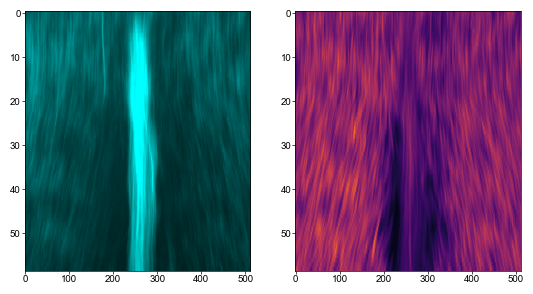

In [46]:
# generate a new colormap
new_cmap_black_cyan = mpl.colors.LinearSegmentedColormap.from_list("black_cyan", ["black", "cyan"])

fig, axs = plt.subplots(1,2)
axs[0].imshow(myo_kymo_average, aspect=10, cmap = new_cmap_black_cyan, vmin=0, vmax=3)
axs[1].imshow(act_kymo_average, aspect=10, cmap = 'inferno', vmin=0, vmax=3)
plt.show()

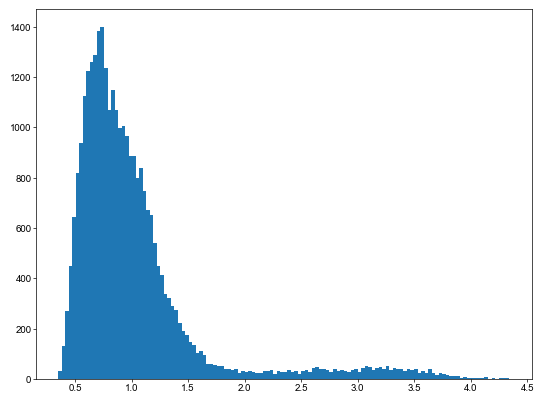

In [47]:
_ = plt.hist(myo_kymo_realigned_average.flatten(), bins=128)

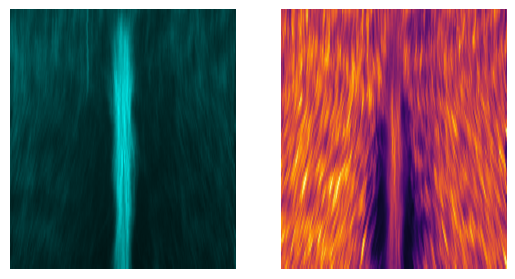

In [57]:
fig, axs = plt.subplots(1,2)
axs[0].imshow(myo_kymo_realigned_average, aspect=10, cmap = new_cmap_black_cyan, vmin=0, vmax=4.5)
axs[1].imshow(act_kymo_realigned_average, aspect=10, cmap = 'inferno', vmin=0, vmax=2)
[ax.set_axis_off() for ax in axs]
plt.savefig('myosin_and_actin_kymo_avg.svg')
plt.show()

# PIV and nematic order

In [82]:
# pivlab rearrangement and divergence calculation

def piv_lab_rearrange(folder, pixel_size, t_interval, every = None):
        
    data_files = []

    for i in os.listdir(folder):
        if '.txt' in i and 'PIVlab' in i:
            data_files.append(i)
    
    frame_num = len(data_files)
    
    x2 = [[]]*frame_num
    y2 = [[]]*frame_num
    u2 = [[]]*frame_num
    v2 = [[]]*frame_num
    
    with open(folder + '/PIVlab_0001.txt') as f:
        first_line = f.readline()
    if first_line[:6] == "x [px]":
        header = 0
    else:
        header = 2

    for frame in range(1,frame_num+1):
        
        if frame < 10:
            frame_name = '000' + str(frame)
        elif frame >=10 and frame < 100:
            frame_name = '00' + str(frame)
        elif frame >= 100:
            frame_name = '0' + str(frame)
            
        data = pd.read_csv(folder + '/PIVlab_'+ frame_name + '.txt',
                            sep=",", header=header)#.fillna(0)
        x2[frame-1] = np.array(data['x [px]'])
        y2[frame-1] = np.array(data['y [px]'])
        u2[frame-1] = np.array(data['u [px/frame]'])
        v2[frame-1] = np.array(data['v [px/frame]'])
        # u2[frame-1][np.isnan(u2[frame-1])] = 0
        # v2[frame-1][np.isnan(v2[frame-1])] = 0
        
    x2 = np.array(x2)
    y2 = np.array(y2)
    u2 = np.array(u2) * pixel_size / t_interval 
    v2 = np.array(v2) * pixel_size / t_interval 
    
    # x3y3 shape: x*y    
    x3 = np.unique(x2)
    y3 = np.unique(y2)    
    
    # xy shape: x, y
    # uv shape: t, x, y
    # vel shape: t, x, y
    x = x2[0].reshape(len(x3), len(y3))
    y = y2[0].reshape(len(x3), len(y3))
    u = u2.reshape(frame_num, len(x3), len(y3))
    v = v2.reshape(frame_num, len(x3), len(y3))
    
    # x2y2u2v2vel2 shape: t, x*y
    u2 = np.nan_to_num(u2)
    v2 = np.nan_to_num(v2)
    
    vel = np.sqrt(v**2 + u**2)
    vel2 = np.nan_to_num(vel.reshape(frame_num, len(y3)*len(x3)))
    
    class Piv_data_rearranged:
        def __init__(self, t_interval, frame_num, x, y, u, v, vel, x2, y2, u2, v2, vel2, x3, y3):
            self.t = np.arange(frame_num-1) * t_interval
            self.f = frame_num
            self.x, self.y, self.u, self.v = x,y,u,v
            self.x2, self.y2, self.u2, self.v2 = x2,y2,u2,v2
            self.x3, self.y3 = x3, y3
            self.vel, self.vel2 = vel, vel2
        
    data = Piv_data_rearranged(t_interval, frame_num, x, y, u, v, vel, x2, y2, u2, v2, vel2, x3, y3)
#     print('shape of [ x y ]: x, y' + '\n' +
#           'shape of [ u v vel ]: t, x, y' + '\n' +
#           'shape of [ x2 y2 u2 v2 vel2 ]: t, x*y' + '\n'
#           'shape of [ x3 y3 ]: x*y')
    
    return data


def divergence(x_i, y_i, u_i, v_i):
    x = np.unique(x_i)
    y = np.unique(y_i)

    du_dx = np.gradient(u_i, x, axis=0)
    dv_dy = np.gradient(v_i, y, axis=1)

    return du_dx + dv_dy

In [83]:
# Write a function to calculate the nematic order
def nematic_order_filter(image, qmin=3, qmax=12):
    ys, xs = image.shape
    image_fft = scipy.fft.fft2(image)
    image_fft = scipy.fft.fftshift(image_fft)
    normalized_squared_modulus = (np.absolute(image_fft))**2
    
    # polar coordinates
    qx, qy = np.meshgrid(np.arange(ys)-(ys-1)/2, np.arange(xs)-(xs-1)/2)
    q = np.sqrt(qx**2 + qy**2)
    theta = np.arctan2(qy, qx)
    
    theta_bins = np.linspace(-np.pi, np.pi, 25)
    # theta_bin_centers = np.unique(theta)

    h_theta = []
    for i in range(24):
        theta_condition = np.logical_and(theta>=theta_bins[i], theta<=theta_bins[i+1] )
        q_condition = np.logical_and(q>=qmin, q<=qmax)
        conditions = np.logical_and(theta_condition, q_condition)
        h_theta.append(np.sum(normalized_squared_modulus[conditions]))
        
    theta_bin_centers = (theta_bins[1:] + theta_bins[:-1])/2
    h_theta = np.array(h_theta)
    h_theta = h_theta/np.sum(h_theta)
    q_xx = -np.sum(h_theta * (np.cos(theta_bin_centers)**2 - 1/2))
    q_xy = -np.sum(h_theta * np.cos(theta_bin_centers) * np.sin(theta_bin_centers))
    
    return [q_xx, q_xy]

# Write a function of applying the nematic order filter to full image
def nematic_order_of_full_image(image, windowsize=30, qmin=3, qmax=12, print_minmax=False):
    ys, xs = image.shape
    regions = {'y':windowsize, 'x':windowsize}
    nematic_order_shape = [ys//regions['y'], xs//regions['x']]

    boundaries = [ys%regions['y'], xs%regions['x']]
    boundary_starts = [int(boundaries[0]/2), int(boundaries[1]/2)]

    nematic_order_q_xx = np.empty(nematic_order_shape)
    nematic_order_q_xy = np.empty(nematic_order_shape)
    nematic_order_x = np.empty(nematic_order_shape)
    nematic_order_y = np.empty(nematic_order_shape)
    
    for j in range(nematic_order_shape[0]):
        for i in range(nematic_order_shape[1]):
            region = image[(boundary_starts[0]+j*regions['y']):(boundary_starts[0]+(j+1)*regions['y']),
                           (boundary_starts[1]+i*regions['x']):(boundary_starts[1]+(i+1)*regions['x'])]
            nematic_order_q_xx[j,i] = nematic_order_filter(region, qmin, qmax)[0]
            nematic_order_q_xy[j,i] = nematic_order_filter(region, qmin, qmax)[1]
            nematic_order_y[j,i] = ((boundary_starts[0]+j*regions['y']) + (boundary_starts[0]+(j+1)*regions['y'])) / 2
            nematic_order_x[j,i] = ((boundary_starts[1]+i*regions['x']) + (boundary_starts[1]+(i+1)*regions['x'])) / 2 

    if print_minmax:
        print('qxx range:', np.nanmin(nematic_order_q_xx), '~', np.nanmax(nematic_order_q_xx))
        print('qxy range:', np.nanmin(nematic_order_q_xy), '~', np.nanmax(nematic_order_q_xy))

    return [nematic_order_x, nematic_order_y, nematic_order_q_xx, nematic_order_q_xy]


# Write a function to convert time
def sec_to_min_and_sec(sec):
    if sec>=0:
        output_min = round(sec//60)
        output_sec = round(sec%60)
        return str(output_min) + ' min ' + str(output_sec) +' sec'
    else:
        sec = -sec
        output_min = round(sec//60)
        output_sec = round(sec%60)
        return '-' + str(output_min) + ' min ' + str(output_sec) +' sec'

# Write a function to create new folder
def create_folder(path):
    isExist = os.path.exists(path) 
    if not isExist:
        os.makedirs(path)

# nematic order to angle
def nematic_to_vector(Q, q):
    theta = np.arctan2(q, Q)/2
    s = np.sqrt(q**2 + Q**2)
    n = [s*np.cos(theta), s*np.sin(theta)]
    return np.array(n)

## Representative views

In [ ]:
i = data_info.loc[data_info['rep_name'] == 'rep155'].index[0]
replicate = data_info.loc[i]

rep_name = replicate.rep_name
rep_folder = rep_name
movie_name = rep_folder + '\\' + rep_name + '_roi4_enlarged.tif'
pixel_size, time_interval = replicate.pixel_size/2, replicate.time_interval
ck1 = replicate.ck1
rep_name = replicate.rep_name

movie = skimage.io.imread(movie_name)
frames, channels, ys, xs = movie.shape

In [213]:
# only run for the first time
no = []
for frame in range(movie.shape[0]):
    no.append(nematic_order_of_full_image(movie[frame, 1], windowsize=40, qmin=1/30*40, qmax=15/30*40, print_minmax=False))
no = np.array(no)

np.save(movie_name[:-4] + '_no.npy', no)
skimage.io.imsave(movie_name[:-4] + '_no.tif', no)

In [229]:
no = np.load(movie_name[:-4] + '_no.npy')

In [230]:
pivtxtfolder_act = rep_folder + '\\' + 'rep155_roi4_piv_act_pivlabtxt'
pivtxtfolder_myo = rep_folder + '\\' + 'rep155_roi4_piv_myo_pivlabtxt'

Piv_act = piv_lab_rearrange(pivtxtfolder_act, pixel_size, time_interval)
Piv_myo = piv_lab_rearrange(pivtxtfolder_myo, pixel_size, time_interval)

In [231]:
q_x, q_y, q_xx, q_xy = no[0, 0], no[0, 1], no[:, 2], no[:, 3]
piv_x, piv_y, piv_u, piv_v = Piv_act.x, Piv_act.y, Piv_act.u*60, Piv_act.v*60
# piv_x, piv_y, piv_u, piv_v = Piv_myo.x, Piv_myo.y, Piv_myo.u*60, Piv_myo.v*60

piv_fs, piv_xs, piv_ys = piv_u.shape

In [ ]:
# correct u and v for symmetry
# piv_u -= np.nanmean(piv_u, axis=(1, 2), keepdims=True)
# piv_v -= np.nanmean(piv_v, axis=(1, 2), keepdims=True)

In [233]:
piv_div = np.zeros_like(piv_u)
for f in range(piv_fs):
    piv_div[f] = divergence(piv_x, piv_y, piv_u[f], piv_v[f])

In [234]:
qanglex, qangley = nematic_to_vector(q_xx, q_xy)
qmag = np.sqrt(q_xx**2 + q_xy**2) 
qanglex_unit, qangley_unit = qanglex/qmag, qangley/qmag

In [235]:
piv_vel = np.sqrt(piv_u**2 + piv_v**2)
piv_u_unit, piv_v_unit = piv_u/piv_vel, piv_v/piv_vel

In [236]:
dev_time = (np.arange(piv_fs) - ck1)*time_interval/60 +42.5

from xint_toolbox import find_closest
frames_to_show = find_closest(dev_time, [40, 43.5, 47.5])[1]

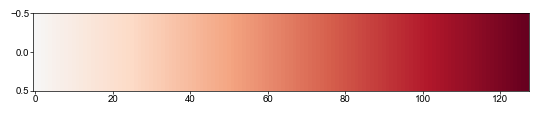

In [237]:
# new cmap
new_reds_cmap = mpl.colors.ListedColormap(mpl.colormaps['RdBu'](np.linspace(0.5,0,1024)))
plt.imshow([np.arange(128)], aspect=20, cmap=new_reds_cmap)
plt.show()

frame 101


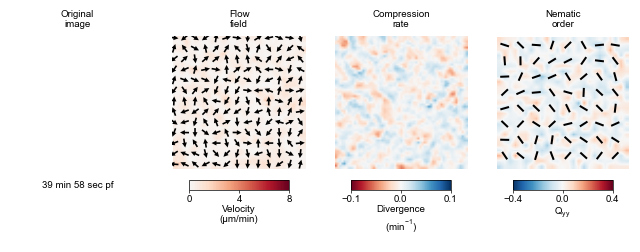

frame 139


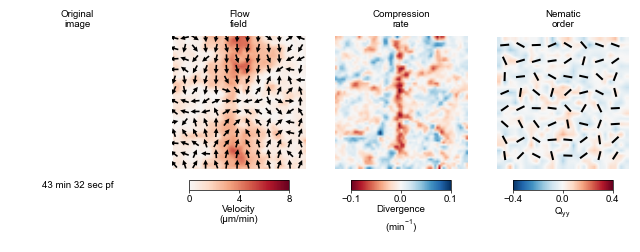

frame 181


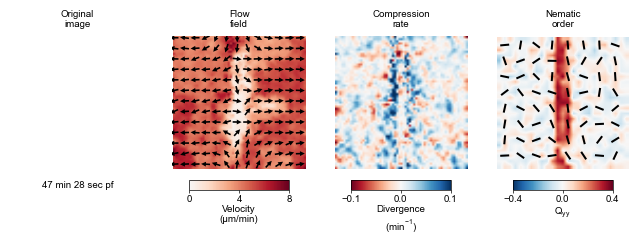

In [238]:
# Create a folder
# folder_name = 'wt-video_actin_flow_div_qxx'
# create_folder(folder_name)
# 
from mpl_toolkits.axes_grid1 import make_axes_locatable

for frame in frames_to_show:
# for frame in range(frames_to_show[0], frames_to_show[2]+10):
    print('frame ' + str(frame))

    interpolation = 'bilinear'
    fig, axs = plt.subplots(2,4,figsize=[8,3], gridspec_kw={"height_ratios": [1,0.03]})

    caxs = []
    for i in range(0,4):
        caxs.append(make_axes_locatable(axs[0,i]).append_axes('bottom', size=0.1, pad=0.1, box_aspect=1/10))

    # panel_1: raw image
    # im0 = axs[0,0].imshow(movie[frame], cmap = 'inferno', vmin = video_vmin, vmax = video_vmax)
    caxs[0].set_axis_off()

    # panel_2: pivlab
    piv_x_step = (piv_x[1,0] - piv_x[0,0]) / 2
    piv_y_step = (piv_y[0,1] - piv_y[0,0]) / 2
    im1 = axs[0,1].imshow(piv_vel[frame], extent=[piv_x[0,0] - piv_x_step, piv_x[-1,-1] + piv_x_step, piv_x[-1,-1] + piv_x_step, piv_x[0,0] - piv_x_step],
                          cmap=new_reds_cmap, vmin=0, vmax=8, interpolation=interpolation)
    
    # axs[0,1].invert_yaxis()
    cb1 = fig.colorbar(im1, cax=caxs[1], orientation='horizontal', label='Velocity\n(\u03BCm/min)', ticks = [0, 4, 8])

    stride = 5
    stride_offset = 0
    axs[0,1].quiver(piv_y[stride_offset::stride, stride_offset::stride], piv_x[stride_offset::stride, stride_offset::stride],
                    piv_v_unit[frame][stride_offset::stride, stride_offset::stride], -piv_u_unit[frame][stride_offset::stride, stride_offset::stride],
                    scale = 15,
                    width = 0.012, pivot = 'mid', headwidth =3, headlength = 3, headaxislength = 3,
                    color='black')

    # panel_3: divergence
    im2 = axs[0,2].imshow(piv_div[frame], extent=[piv_x[0,0] - piv_x_step, piv_x[-1,-1] + piv_x_step, piv_x[-1,-1] + piv_x_step, piv_x[0,0] - piv_x_step],
                        cmap='RdBu', vmin=-0.1, vmax=0.1, interpolation=interpolation)
    cb2 = fig.colorbar(im2, cax=caxs[2], orientation='horizontal', label='Divergence\n($\\mathregular{min^{-1}}$)', ticks = [-0.1, 0, 0.1])

    # panel_4: nematic order
    qx_step = (q_x[0,1] - q_x[0,0])/2
    qy_step = (q_y[1,0] - q_y[0,0])/2
    im3 = axs[0,3].imshow(q_xx[frame].T, extent=[q_y[0,0] - qy_step, q_y[-1, 0] + qy_step, q_x[-1,-1]+qx_step, q_x[0,0]-qx_step],
                          cmap='RdBu_r', vmin=-0.4, vmax=0.4, interpolation=interpolation)
    cb3 = fig.colorbar(im3, cax=caxs[3], orientation='horizontal', label='$\\mathregular{Q_{yy}}$', ticks = [-0.4, 0.0, 0.4])

    stride = 3
    stride_offset = 1
    axs[0,3].quiver(q_y[stride_offset::stride, stride_offset::stride], q_x[stride_offset::stride, stride_offset::stride], 
                    -qangley_unit[frame][stride_offset::stride, stride_offset::stride], -qanglex_unit[frame][stride_offset::stride, stride_offset::stride], 
                    color='black',
                    scale = 15, width = 0.015, pivot = 'mid', headwidth =0, headlength = 0, headaxislength = 0)

    # time
    caxs[0].text(0.5, 0.5, sec_to_min_and_sec(dev_time[frame]*60) +' pf', color='black', fontsize=7, va='center', ha='center')

    # titles
    axs[0,0].set_title('Original\nimage', fontsize=7)
    axs[0,1].set_title('Flow\nfield', fontsize=7)
    axs[0,2].set_title('Compression\nrate', fontsize=7)
    axs[0,3].set_title('Nematic\norder', fontsize=7)

    [axs[0, i].set_axis_off() for i in range(4)]
    [axs[1, i].set_axis_off() for i in range(4)]
    [axs[0, i].set_aspect('equal') for i in range(4)]

    # ranges
    [axs[0, i].set_xlim(0, 0+1024) for i in range(4)]
    [axs[0, i].set_ylim(0+1024, 0) for i in range(4)]

    # fig.align_labels(axs=caxs)
    # fig.align_titles()

    # plt.savefig(folder_name + '/f' + str(frame) + '.svg')
    # plt.savefig(folder_name + '/f' + str(frame) + '.png', dpi=500, pad_inches = 0)
    plt.show()


In [239]:
i = data_info.loc[data_info['rep_name'] == 'rep156'].index[0]
replicate = data_info.loc[i]

rep_name = replicate.rep_name
rep_folder = rep_name
movie_name = rep_folder + '\\' + rep_name + '_roi5_f226-228.tif'
pixel_size, time_interval = replicate.pixel_size/2, replicate.time_interval
ck1 = replicate.ck1
rep_name = replicate.rep_name

movie = skimage.io.imread(movie_name)
frames, channels, ys, xs = movie.shape

In [240]:
# only run for the first time
no = []
for frame in range(movie.shape[0]):
    no.append(nematic_order_of_full_image(movie[frame, 1], windowsize=40, qmin=1/30*40, qmax=15/30*40, print_minmax=False))
no = np.array(no)

np.save(movie_name[:-4] + '_no.npy', no)
skimage.io.imsave(movie_name[:-4] + '_no.tif', no)

In [241]:
no = np.load(movie_name[:-4] + '_no.npy')

In [242]:
pivtxtfolder_act = rep_folder + '\\' + 'rep156_roi5_f226-228_piv_act'
# pivtxtfolder_myo = rep_folder + '\\' + 'rep155_roi4_piv_myo_pivlabtxt'

Piv_act = piv_lab_rearrange(pivtxtfolder_act, pixel_size, time_interval)
# Piv_myo = piv_lab_rearrange(pivtxtfolder_myo, pixel_size, time_interval)

In [243]:
q_x, q_y, q_xx, q_xy = no[0, 0], no[0, 1], no[:, 2], no[:, 3]
piv_x, piv_y, piv_u, piv_v = Piv_act.x, Piv_act.y, Piv_act.u*60, Piv_act.v*60
# piv_x, piv_y, piv_u, piv_v = Piv_myo.x, Piv_myo.y, Piv_myo.u*60, Piv_myo.v*60

piv_fs, piv_xs, piv_ys = piv_u.shape

In [244]:
piv_div = np.zeros_like(piv_u)
for f in range(piv_fs):
    piv_div[f] = divergence(piv_x, piv_y, piv_u[f], piv_v[f])

In [245]:
qanglex, qangley = nematic_to_vector(q_xx, q_xy)
qmag = np.sqrt(q_xx**2 + q_xy**2) 
qanglex_unit, qangley_unit = qanglex/qmag, qangley/qmag

In [246]:
piv_vel = np.sqrt(piv_u**2 + piv_v**2)
piv_u_unit, piv_v_unit = piv_u/piv_vel, piv_v/piv_vel

In [249]:
# dev_time = (np.arange(piv_fs) - ck1)*time_interval/60 +42.5

# from xint_toolbox import find_closest
# frames_to_show = find_closest(dev_time, [40, 43.5, 47.5])[1]
frames_to_show = [0]

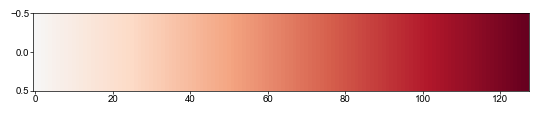

In [250]:
# new cmap
new_reds_cmap = mpl.colors.ListedColormap(mpl.colormaps['RdBu'](np.linspace(0.5,0,1024)))
plt.imshow([np.arange(128)], aspect=20, cmap=new_reds_cmap)
plt.show()

frame 0


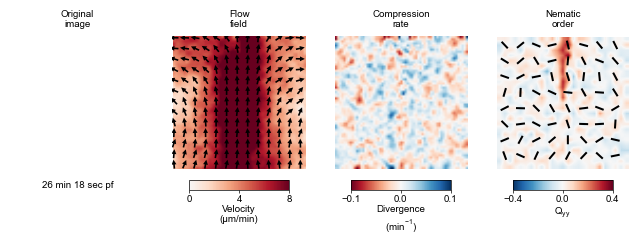

In [251]:
# Create a folder
# folder_name = 'wt-video_actin_flow_div_qxx'
# create_folder(folder_name)
# 
from mpl_toolkits.axes_grid1 import make_axes_locatable

for frame in frames_to_show:
# for frame in range(frames_to_show[0], frames_to_show[2]+10):
    print('frame ' + str(frame))

    interpolation = 'bilinear'
    fig, axs = plt.subplots(2,4,figsize=[8,3], gridspec_kw={"height_ratios": [1,0.03]})

    caxs = []
    for i in range(0,4):
        caxs.append(make_axes_locatable(axs[0,i]).append_axes('bottom', size=0.1, pad=0.1, box_aspect=1/10))

    # panel_1: raw image
    # im0 = axs[0,0].imshow(movie[frame], cmap = 'inferno', vmin = video_vmin, vmax = video_vmax)
    caxs[0].set_axis_off()

    # panel_2: pivlab
    piv_x_step = (piv_x[1,0] - piv_x[0,0]) / 2
    piv_y_step = (piv_y[0,1] - piv_y[0,0]) / 2
    im1 = axs[0,1].imshow(piv_vel[frame], extent=[piv_x[0,0] - piv_x_step, piv_x[-1,-1] + piv_x_step, piv_x[-1,-1] + piv_x_step, piv_x[0,0] - piv_x_step],
                          cmap=new_reds_cmap, vmin=0, vmax=8, interpolation=interpolation)
    
    # axs[0,1].invert_yaxis()
    cb1 = fig.colorbar(im1, cax=caxs[1], orientation='horizontal', label='Velocity\n(\u03BCm/min)', ticks = [0, 4, 8])

    stride = 5
    stride_offset = 0
    axs[0,1].quiver(piv_y[stride_offset::stride, stride_offset::stride], piv_x[stride_offset::stride, stride_offset::stride],
                    piv_v_unit[frame][stride_offset::stride, stride_offset::stride], -piv_u_unit[frame][stride_offset::stride, stride_offset::stride],
                    scale = 15,
                    width = 0.012, pivot = 'mid', headwidth =3, headlength = 3, headaxislength = 3,
                    color='black')

    # panel_3: divergence
    im2 = axs[0,2].imshow(piv_div[frame], extent=[piv_x[0,0] - piv_x_step, piv_x[-1,-1] + piv_x_step, piv_x[-1,-1] + piv_x_step, piv_x[0,0] - piv_x_step],
                        cmap='RdBu', vmin=-0.1, vmax=0.1, interpolation=interpolation)
    cb2 = fig.colorbar(im2, cax=caxs[2], orientation='horizontal', label='Divergence\n($\\mathregular{min^{-1}}$)', ticks = [-0.1, 0, 0.1])

    # panel_4: nematic order
    qx_step = (q_x[0,1] - q_x[0,0])/2
    qy_step = (q_y[1,0] - q_y[0,0])/2
    im3 = axs[0,3].imshow(q_xx[frame].T, extent=[q_y[0,0] - qy_step, q_y[-1, 0] + qy_step, q_x[-1,-1]+qx_step, q_x[0,0]-qx_step],
                          cmap='RdBu_r', vmin=-0.4, vmax=0.4, interpolation=interpolation)
    cb3 = fig.colorbar(im3, cax=caxs[3], orientation='horizontal', label='$\\mathregular{Q_{yy}}$', ticks = [-0.4, 0.0, 0.4])

    stride = 3
    stride_offset = 1
    axs[0,3].quiver(q_y[stride_offset::stride, stride_offset::stride], q_x[stride_offset::stride, stride_offset::stride], 
                    -qangley_unit[frame][stride_offset::stride, stride_offset::stride], -qanglex_unit[frame][stride_offset::stride, stride_offset::stride], 
                    color='black',
                    scale = 15, width = 0.015, pivot = 'mid', headwidth =0, headlength = 0, headaxislength = 0)

    # time
    caxs[0].text(0.5, 0.5, sec_to_min_and_sec(dev_time[frame]*60) +' pf', color='black', fontsize=7, va='center', ha='center')

    # titles
    axs[0,0].set_title('Original\nimage', fontsize=7)
    axs[0,1].set_title('Flow\nfield', fontsize=7)
    axs[0,2].set_title('Compression\nrate', fontsize=7)
    axs[0,3].set_title('Nematic\norder', fontsize=7)

    [axs[0, i].set_axis_off() for i in range(4)]
    [axs[1, i].set_axis_off() for i in range(4)]
    [axs[0, i].set_aspect('equal') for i in range(4)]

    # ranges
    [axs[0, i].set_xlim(0, 0+1024) for i in range(4)]
    [axs[0, i].set_ylim(0+1024, 0) for i in range(4)]

    # fig.align_labels(axs=caxs)
    # fig.align_titles()

    # plt.savefig(folder_name + '/f' + str(frame) + '.svg')
    # plt.savefig(folder_name + '/f' + str(frame) + '.png', dpi=500, pad_inches = 0)
    plt.show()
